In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Cognifyz_Restaurant_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 9551
Columns: 21


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Currency,Has Table booking,Has Online delivery,Is delivering now,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,Botswana Pula(P),Yes,No,No,No,3,4.8,Dark Green,Excellent,314
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,Botswana Pula(P),Yes,No,No,No,3,4.5,Dark Green,Excellent,591
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,Botswana Pula(P),Yes,No,No,No,4,4.4,Green,Very Good,270
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,Botswana Pula(P),No,No,No,No,4,4.9,Dark Green,Excellent,365
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,Botswana Pula(P),Yes,No,No,No,4,4.8,Dark Green,Excellent,229


# TASK 1 : Data Exploration and Preprocessing

In [3]:
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Shape of dataset: (9551, 21)

Column names:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes']

Data types:
Restaurant ID             int64
Restaurant Name          object
Country Code              int64
City                     object
Address                  object
Locality                 object
Locality Verbose         object
Longitude               float64
Latitude                float64
Cuisines                 object
Average Cost for two      int64
Currency                 object
Has Table booking        object
Has Online delivery      object
Is delivering now        object
Switch to order menu     object
Price range               int64
Aggregate rating        float64
Rating color             o

In [4]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                9
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (9551, 21)


In [6]:
df["Cuisines"] = df["Cuisines"].fillna("Unknown")
df["City"] = df["City"].fillna("Unknown")

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Restaurant ID           0
Restaurant Name         0
Country Code            0
City                    0
Address                 0
Locality                0
Locality Verbose        0
Longitude               0
Latitude                0
Cuisines                0
Average Cost for two    0
Currency                0
Has Table booking       0
Has Online delivery     0
Is delivering now       0
Switch to order menu    0
Price range             0
Aggregate rating        0
Rating color            0
Rating text             0
Votes                   0
dtype: int64


In [7]:
print(df["Aggregate rating"].describe())

print("\nRating counts:")
print(df["Aggregate rating"].value_counts().sort_index())

count    9551.000000
mean        2.666370
std         1.516378
min         0.000000
25%         2.500000
50%         3.200000
75%         3.700000
max         4.900000
Name: Aggregate rating, dtype: float64

Rating counts:
Aggregate rating
0.0    2148
1.8       1
1.9       2
2.0       7
2.1      15
2.2      27
2.3      47
2.4      87
2.5     110
2.6     191
2.7     250
2.8     315
2.9     381
3.0     468
3.1     519
3.2     522
3.3     483
3.4     498
3.5     480
3.6     458
3.7     427
3.8     400
3.9     335
4.0     266
4.1     274
4.2     221
4.3     174
4.4     144
4.5      95
4.6      78
4.7      42
4.8      25
4.9      61
Name: count, dtype: int64


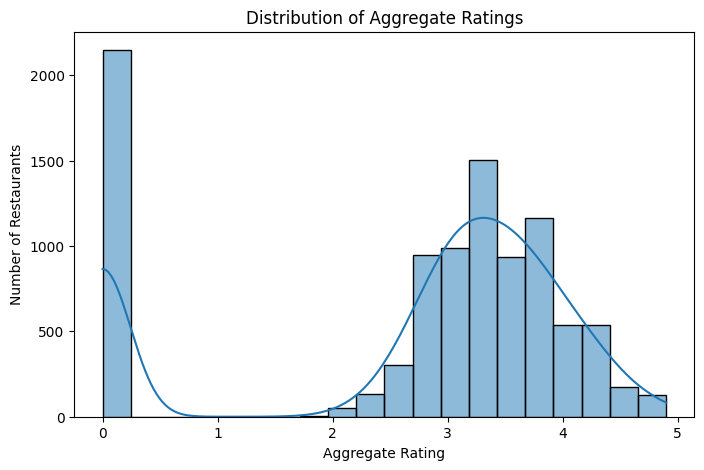

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df["Aggregate rating"], bins=20, kde=True)

plt.title("Distribution of Aggregate Ratings")
plt.xlabel("Aggregate Rating")
plt.ylabel("Number of Restaurants")

plt.show()

Aggregate rating
0-2    2158
2-3    1891
3-4    4388
4-5    1114
Name: count, dtype: int64


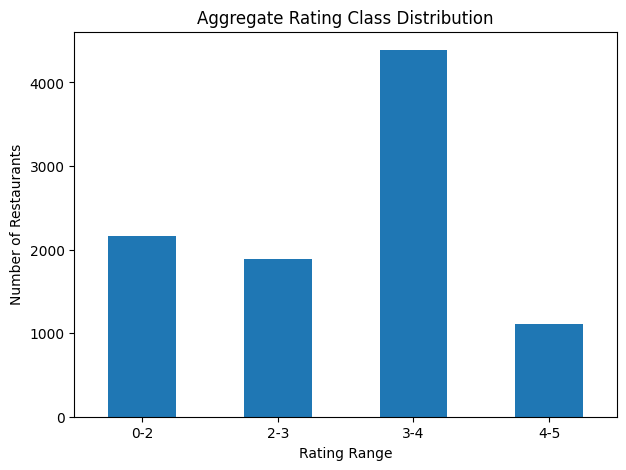

In [9]:
rating_classes = pd.cut(
    df["Aggregate rating"],
    bins=[-1, 2, 3, 4, 5],
    labels=["0-2", "2-3", "3-4", "4-5"]
)

print(rating_classes.value_counts().sort_index())

plt.figure(figsize=(7,5))

rating_classes.value_counts().sort_index().plot(kind="bar")

plt.title("Aggregate Rating Class Distribution")
plt.xlabel("Rating Range")
plt.ylabel("Number of Restaurants")

plt.xticks(rotation=0)
plt.show()

# TASK 2 : Descriptive Analysis

In [10]:
print("Mean:")
print(df.select_dtypes(include=np.number).mean())

print("\nMedian:")
print(df.select_dtypes(include=np.number).median())

print("\nStandard Deviation:")
print(df.select_dtypes(include=np.number).std())

Mean:
Restaurant ID           9.051128e+06
Country Code            1.836562e+01
Longitude               6.412657e+01
Latitude                2.585438e+01
Average Cost for two    1.199211e+03
Price range             1.804837e+00
Aggregate rating        2.666370e+00
Votes                   1.569097e+02
dtype: float64

Median:
Restaurant ID           6.004089e+06
Country Code            1.000000e+00
Longitude               7.719196e+01
Latitude                2.857047e+01
Average Cost for two    4.000000e+02
Price range             2.000000e+00
Aggregate rating        3.200000e+00
Votes                   3.100000e+01
dtype: float64

Standard Deviation:
Restaurant ID           8.791521e+06
Country Code            5.675055e+01
Longitude               4.146706e+01
Latitude                1.100794e+01
Average Cost for two    1.612118e+04
Price range             9.056088e-01
Aggregate rating        1.516378e+00
Votes                   4.301691e+02
dtype: float64


Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


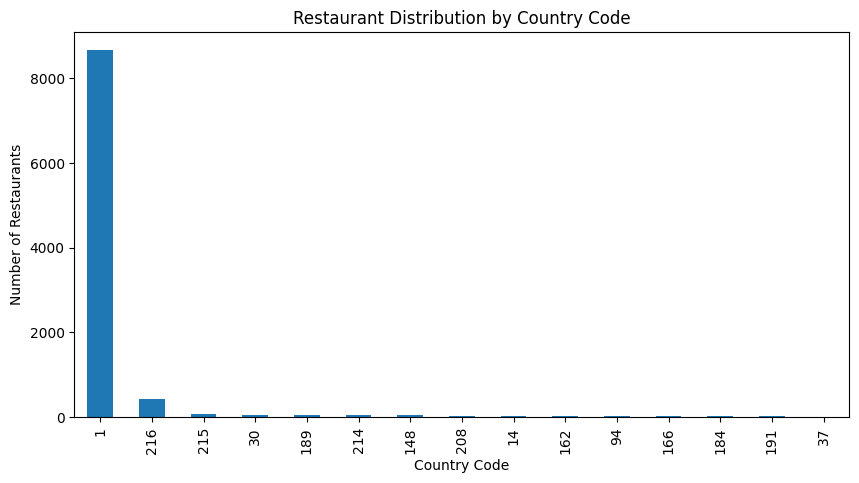

In [11]:
country_counts = df["Country Code"].value_counts()

print(country_counts.head(15))

plt.figure(figsize=(10,5))

country_counts.head(15).plot(kind="bar")

plt.title("Restaurant Distribution by Country Code")
plt.xlabel("Country Code")
plt.ylabel("Number of Restaurants")

plt.show()

City
New Delhi       5473
Gurgaon         1118
Noida           1080
Faridabad        251
Ghaziabad         25
Bhubaneshwar      21
Lucknow           21
Ahmedabad         21
Amritsar          21
Guwahati          21
Name: count, dtype: int64


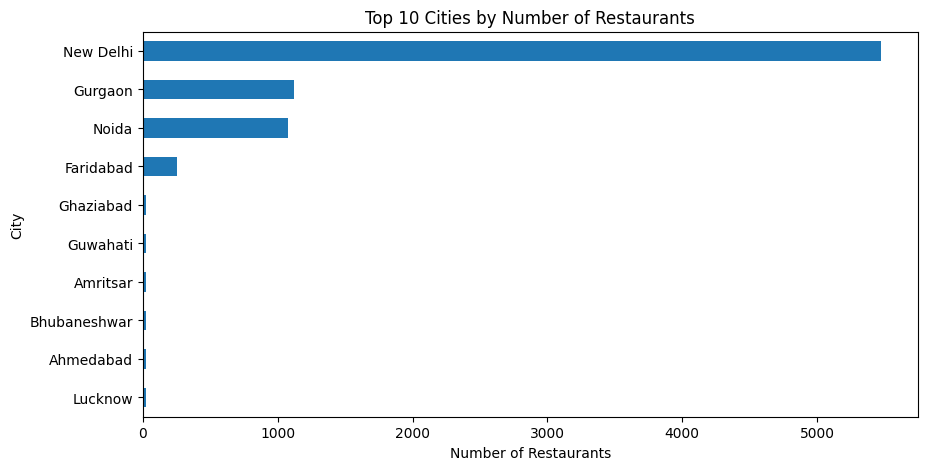

In [12]:
city_counts = df["City"].value_counts().head(10)

print(city_counts)

plt.figure(figsize=(10,5))

city_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Restaurants")
plt.xlabel("Number of Restaurants")
plt.ylabel("City")

plt.show()

Cuisines
North Indian                      936
North Indian, Chinese             511
Fast Food                         354
Chinese                           354
North Indian, Mughlai             334
Cafe                              299
Bakery                            218
North Indian, Mughlai, Chinese    197
Bakery, Desserts                  170
Street Food                       149
Name: count, dtype: int64


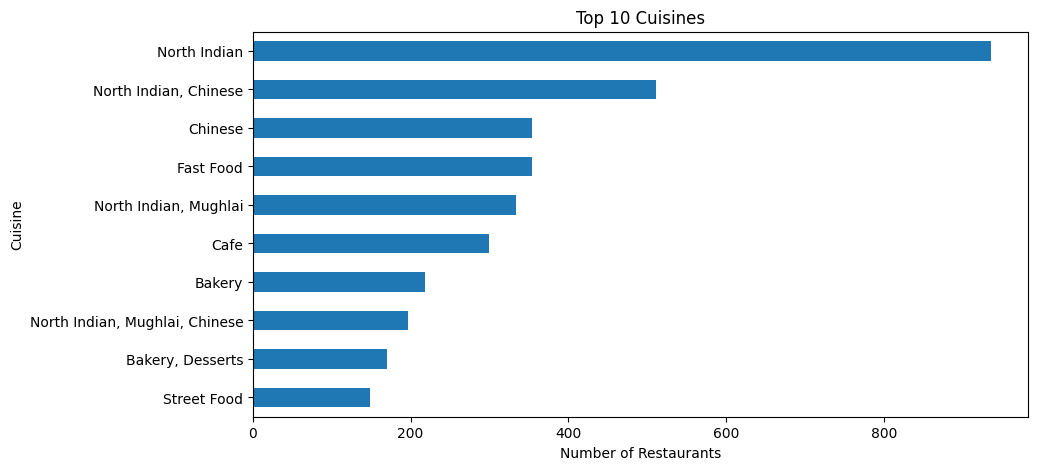

In [13]:
cuisine_counts = df["Cuisines"].value_counts().head(10)

print(cuisine_counts)

plt.figure(figsize=(10,5))

cuisine_counts.sort_values().plot(kind="barh")

plt.title("Top 10 Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

plt.show()

# TASK 3 : Geospatial Analysis

In [14]:
print(df[["Latitude", "Longitude"]].describe())

          Latitude    Longitude
count  9551.000000  9551.000000
mean     25.854381    64.126574
std      11.007935    41.467058
min     -41.330428  -157.948486
25%      28.478713    77.081343
50%      28.570469    77.191964
75%      28.642758    77.282006
max      55.976980   174.832089


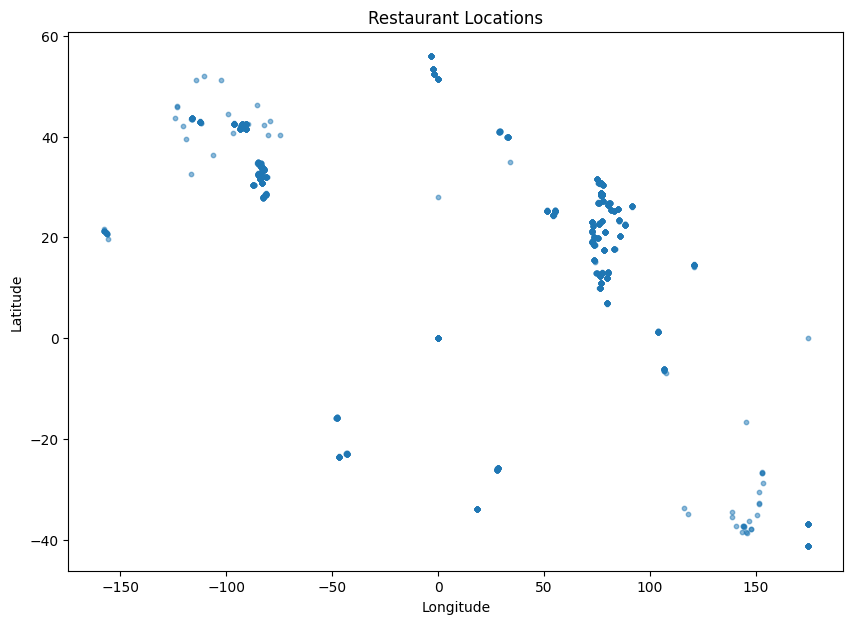

In [15]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    alpha=0.5,
    s=10
)

plt.title("Restaurant Locations")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

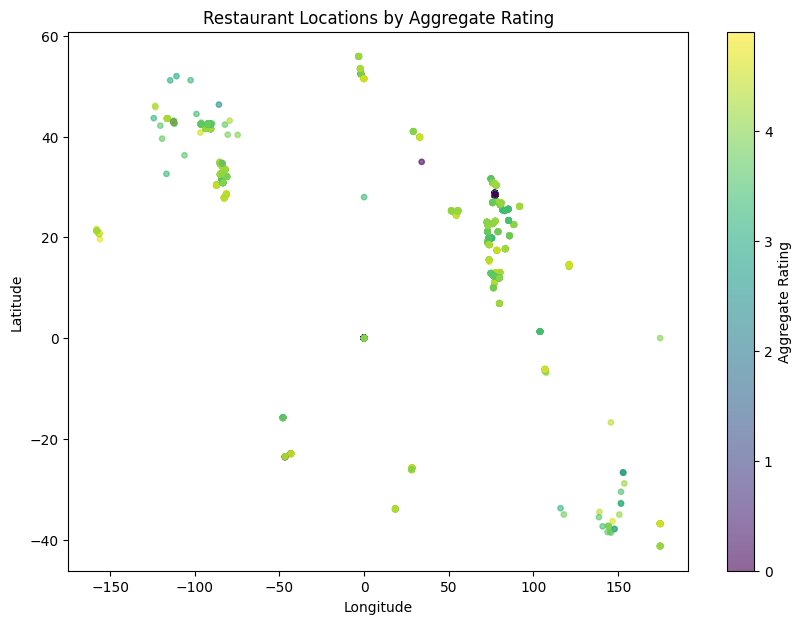

In [16]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["Longitude"],
    df["Latitude"],
    c=df["Aggregate rating"],
    cmap="viridis",
    alpha=0.6,
    s=15
)

plt.colorbar(label="Aggregate Rating")

plt.title("Restaurant Locations by Aggregate Rating")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [17]:
city_rating = (
    df.groupby("City")["Aggregate rating"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(city_rating)

City
Inner City          4.900000
Quezon City         4.800000
Makati City         4.650000
Pasig City          4.633333
Mandaluyong City    4.625000
Beechworth          4.600000
London              4.535000
Taguig City         4.525000
Secunderabad        4.500000
Lincoln             4.500000
Name: Aggregate rating, dtype: float64


In [18]:
country_distribution = df["Country Code"].value_counts()

print("Number of restaurants by country:")
print(country_distribution)

Number of restaurants by country:
Country Code
1      8652
216     434
215      80
30       60
189      60
214      60
148      40
208      34
14       24
162      22
94       21
166      20
184      20
191      20
37        4
Name: count, dtype: int64


# TASK 4 : Table Booking and Online Delivery

In [19]:
table_booking = df["Has Table booking"].value_counts(normalize=True) * 100

print(table_booking)

Has Table booking
No     87.875615
Yes    12.124385
Name: proportion, dtype: float64


In [20]:
online_delivery = df["Has Online delivery"].value_counts(normalize=True) * 100

print(online_delivery)

Has Online delivery
No     74.337766
Yes    25.662234
Name: proportion, dtype: float64


Has Table booking
No     2.559359
Yes    3.441969
Name: Aggregate rating, dtype: float64


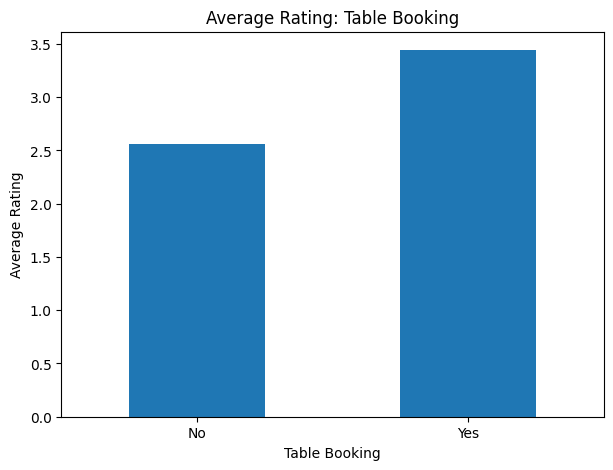

In [21]:
booking_rating = df.groupby(
    "Has Table booking"
)["Aggregate rating"].mean()

print(booking_rating)

booking_rating.plot(kind="bar", figsize=(7,5))

plt.title("Average Rating: Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)
plt.show()

In [22]:
delivery_price = pd.crosstab(
    df["Price range"],
    df["Has Online delivery"],
    normalize="index"
) * 100

print(delivery_price)

Has Online delivery         No        Yes
Price range                              
1                    84.225923  15.774077
2                    58.689367  41.310633
3                    70.809659  29.190341
4                    90.955631   9.044369


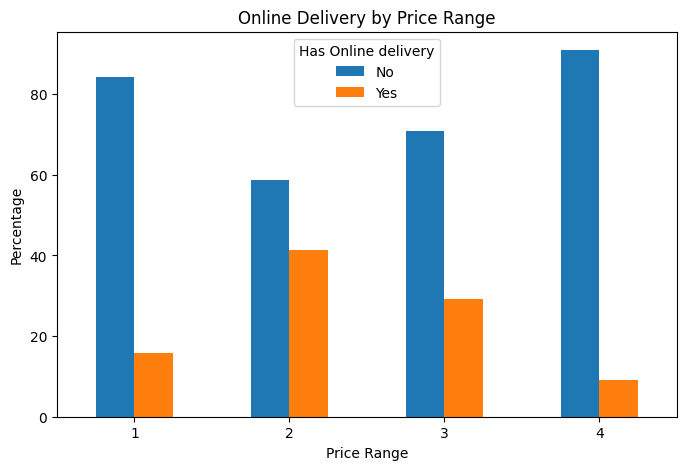

In [23]:
delivery_price.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Online Delivery by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Percentage")

plt.xticks(rotation=0)
plt.show()

# TASK 5 : Price Range Analysis

In [24]:
price_counts = df["Price range"].value_counts().sort_index()

print(price_counts)

print(
    "\nMost common price range:",
    price_counts.idxmax()
)

Price range
1    4444
2    3113
3    1408
4     586
Name: count, dtype: int64

Most common price range: 1


In [25]:
price_rating = df.groupby(
    "Price range"
)["Aggregate rating"].mean()

print(price_rating)

Price range
1    1.999887
2    2.941054
3    3.683381
4    3.817918
Name: Aggregate rating, dtype: float64


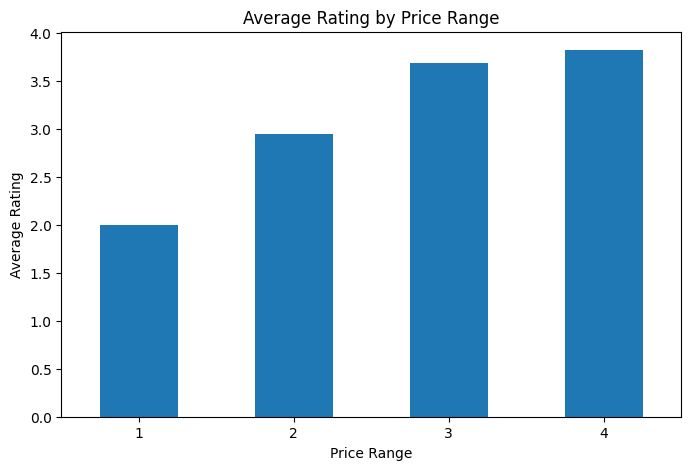

In [26]:
price_rating.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rating by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Rating")

plt.xticks(rotation=0)
plt.show()

In [27]:
highest_price_rating = price_rating.idxmax()

print(
    "Price range with highest average rating:",
    highest_price_rating
)

print(
    "Average rating:",
    price_rating.max()
)

Price range with highest average rating: 4
Average rating: 3.8179180887372017


# TASK 6 : Feature Engineering

In [28]:
df["Restaurant Name Length"] = df["Restaurant Name"].astype(str).str.len()

df[["Restaurant Name", "Restaurant Name Length"]].head()

,Restaurant Name,Restaurant Name Length
0,Le Petit Souffle,16
1,Izakaya Kikufuji,16
2,Heat - Edsa Shangri-La,22
3,Ooma,4
4,Sambo Kojin,11


In [29]:
df["Address Length"] = df["Address"].astype(str).str.len()

df[["Address", "Address Length"]].head()

,Address,Address Length
0,"Third Floor, Century City Mall, Kalayaan Avenu...",71
1,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...",67
2,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...",56
3,"Third Floor, Mega Fashion Hall, SM Megamall, O...",70
4,"Third Floor, Mega Atrium, SM Megamall, Ortigas...",64


In [30]:
df["Table Booking Binary"] = df["Has Table booking"].map({
    "Yes": 1,
    "No": 0
})

df[["Has Table booking", "Table Booking Binary"]].head()

,Has Table booking,Table Booking Binary
0,Yes,1
1,Yes,1
2,Yes,1
3,No,0
4,Yes,1


In [31]:
df["Online Delivery Binary"] = df["Has Online delivery"].map({
    "Yes": 1,
    "No": 0
})

df[["Has Online delivery", "Online Delivery Binary"]].head()

,Has Online delivery,Online Delivery Binary
0,No,0
1,No,0
2,No,0
3,No,0
4,No,0


# FINAL ANALYSIS

In [32]:
numeric_df = df.select_dtypes(include=np.number)

correlation = numeric_df.corr()["Aggregate rating"].sort_values(
    ascending=False
)

print(correlation)

Aggregate rating          1.000000
Price range               0.437944
Votes                     0.313691
Country Code              0.282189
Online Delivery Binary    0.225699
Table Booking Binary      0.189998
Average Cost for two      0.051792
Address Length            0.002334
Latitude                  0.000516
Restaurant Name Length   -0.035178
Longitude                -0.116818
Restaurant ID            -0.326212
Name: Aggregate rating, dtype: float64


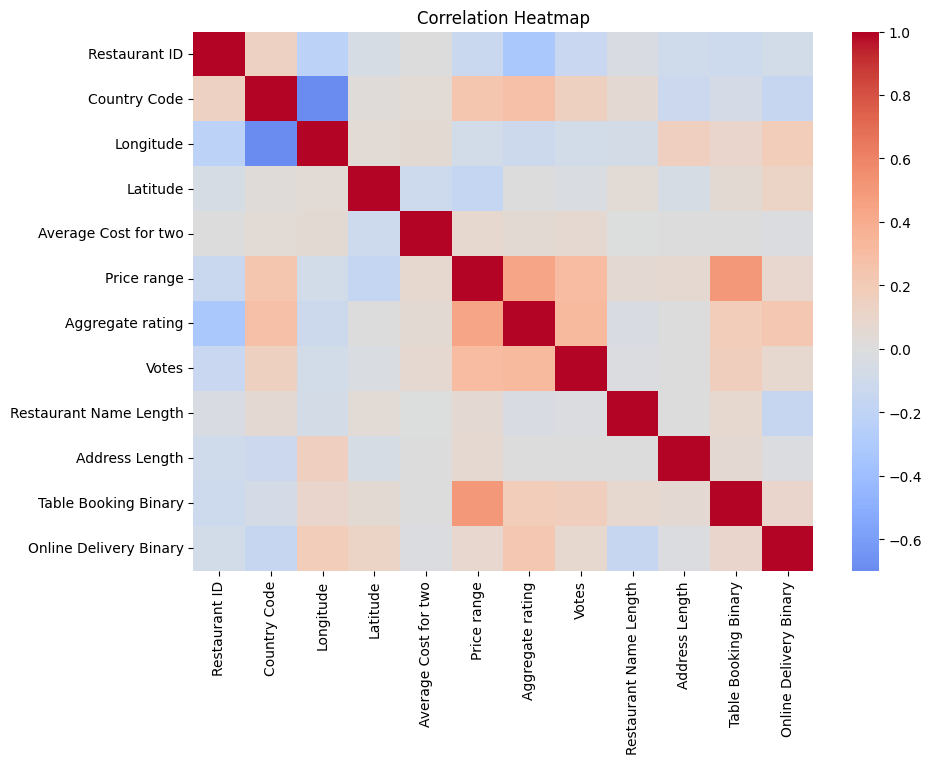

In [33]:
plt.figure(figsize=(10,7))

sns.heatmap(
    numeric_df.corr(),
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")

plt.show()

In [34]:
print("Final dataset shape:", df.shape)

print("\nFinal columns:")
print(df.columns.tolist())

df.head()

Final dataset shape: (9551, 25)

Final columns:
['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address', 'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines', 'Average Cost for two', 'Currency', 'Has Table booking', 'Has Online delivery', 'Is delivering now', 'Switch to order menu', 'Price range', 'Aggregate rating', 'Rating color', 'Rating text', 'Votes', 'Restaurant Name Length', 'Address Length', 'Table Booking Binary', 'Online Delivery Binary']


,Restaurant ID,Restaurant Name,Country Code,City,Address,Locality,Locality Verbose,Longitude,Latitude,Cuisines,...,Switch to order menu,Price range,Aggregate rating,Rating color,Rating text,Votes,Restaurant Name Length,Address Length,Table Booking Binary,Online Delivery Binary
0,6317637,Le Petit Souffle,162,Makati City,"Third Floor, Century City Mall, Kalayaan Avenu...","Century City Mall, Poblacion, Makati City","Century City Mall, Poblacion, Makati City, Mak...",121.027535,14.565443,"French, Japanese, Desserts",...,No,3,4.8,Dark Green,Excellent,314,16,71,1,0
1,6304287,Izakaya Kikufuji,162,Makati City,"Little Tokyo, 2277 Chino Roces Avenue, Legaspi...","Little Tokyo, Legaspi Village, Makati City","Little Tokyo, Legaspi Village, Makati City, Ma...",121.014101,14.553708,Japanese,...,No,3,4.5,Dark Green,Excellent,591,16,67,1,0
2,6300002,Heat - Edsa Shangri-La,162,Mandaluyong City,"Edsa Shangri-La, 1 Garden Way, Ortigas, Mandal...","Edsa Shangri-La, Ortigas, Mandaluyong City","Edsa Shangri-La, Ortigas, Mandaluyong City, Ma...",121.056831,14.581404,"Seafood, Asian, Filipino, Indian",...,No,4,4.4,Green,Very Good,270,22,56,1,0
3,6318506,Ooma,162,Mandaluyong City,"Third Floor, Mega Fashion Hall, SM Megamall, O...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.056475,14.585318,"Japanese, Sushi",...,No,4,4.9,Dark Green,Excellent,365,4,70,0,0
4,6314302,Sambo Kojin,162,Mandaluyong City,"Third Floor, Mega Atrium, SM Megamall, Ortigas...","SM Megamall, Ortigas, Mandaluyong City","SM Megamall, Ortigas, Mandaluyong City, Mandal...",121.057508,14.584450,"Japanese, Korean",...,No,4,4.8,Dark Green,Excellent,229,11,64,1,0


In [35]:
df.to_csv(
    "Cognifyz_Cleaned_Restaurant_Data.csv",
    index=False
)

print("Cleaned dataset saved!")

Cleaned dataset saved!


# Project completion

In [36]:
print("=" * 60)
print("COGNIFYZ TECHNOLOGIES")
print("RESTAURANT DATA ANALYSIS")
print("=" * 60)

print("\nLEVEL 1")
print("✓ Data Exploration and Preprocessing")
print("✓ Descriptive Analysis")
print("✓ Geospatial Analysis")

print("\nLEVEL 2")
print("✓ Table Booking and Online Delivery")
print("✓ Price Range Analysis")
print("✓ Feature Engineering")

print("\nPROJECT COMPLETED SUCCESSFULLY!")

COGNIFYZ TECHNOLOGIES
RESTAURANT DATA ANALYSIS

LEVEL 1
✓ Data Exploration and Preprocessing
✓ Descriptive Analysis
✓ Geospatial Analysis

LEVEL 2
✓ Table Booking and Online Delivery
✓ Price Range Analysis
✓ Feature Engineering

PROJECT COMPLETED SUCCESSFULLY!
